In [2]:
import numpy as np
np.random.seed(1234)
from VR_trajectories import *
import gudhi as gd
from gudhi import CoverComplex
from gudhi import SimplexTree
import matplotlib.pyplot as plt
from sklearn import datasets
import networkx as nx
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from scipy.spatial.distance import cdist
from itertools import combinations
from mpl_toolkits.mplot3d import art3d

# Toy dataset: two concentric circumferences

We generate the dataset

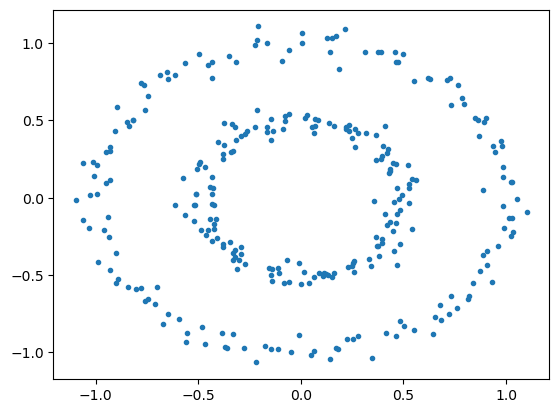

In [3]:
#%% Experiment 1
#%% Generate a dataset for demonstration
def generate_sample_data():
    """Generate a simple dataset for demonstration"""
    n_points = 300
    X, y = datasets.make_circles(n_samples=n_points, factor=0.5, noise=0.05)
    return X, y

X, y = generate_sample_data()
points = X
plt.plot(points[:,0],points[:,1],'.')
plt.show()    

Model training/loading

In [5]:
#%% Model training
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model



model = Sequential([
    layers.Input(shape=(2,),name='input_layer'),
    layers.Dense(3, activation='sigmoid' ,name='hidden_layer'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])


# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

#model.fit(X, y, epochs=2000,batch_size = 16)

#model.save('experiment.h')
model = keras.models.load_model('experiment.h')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_layer (Dense)        (None, 3)                 9         
                                                                 
 output_layer (Dense)        (None, 1)                 4         
                                                                 
Total params: 13
Trainable params: 13
Non-trainable params: 0
_________________________________________________________________


Plot decision boundary

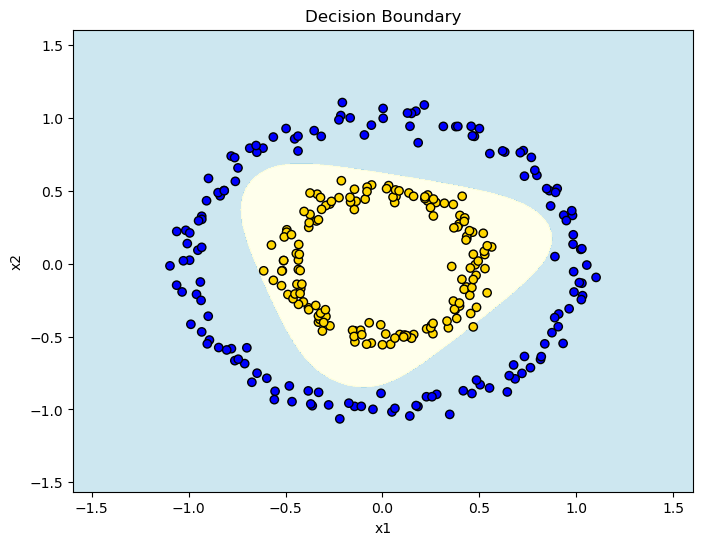

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, steps=1000, cmap='Paired'):
    """
    Plots the decision boundary of a trained Keras model.

    Parameters:
    - model: Trained Keras model
    - X: Input data (2D features)
    - y: Labels
    - steps: Number of grid points in each dimension
    - cmap: Color map for plotting
    """

    # Define bounds of the domain
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Generate a grid of points with distance 1/steps between them
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))

    # Predict on the grid points
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred_probs = model.predict(grid, verbose=0)
    
    # Handle both binary and multi-class classification
    if pred_probs.shape[1] > 1:
        Z = np.argmax(pred_probs, axis=1)
    else:
        Z = (pred_probs > 0.5).astype(int).flatten()

    Z = Z.reshape(xx.shape)

    # Create color maps
        # Blue for class 0, Yellow for class 1
    cmap_light = ListedColormap(['#ADD8E6', '#FFFFE0'])  # Light blue, light yellow
    cmap_bold = ListedColormap(['#0000FF', '#FFD700'])  # Blue, golden yellow


    # Plot contour and training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k')
    plt.title("Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

    
# Assuming you have:
# - a trained model: `model`
# - 2D input data: `X_train`
# - labels: `y_train`

plot_decision_boundary(model, X, y)


## Layer persistence computation

10/10 [==============================] - 0s 1ms/step


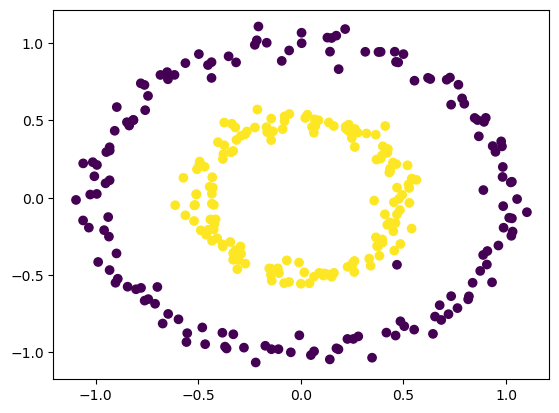

10/10 [==============================] - 0s 953us/step


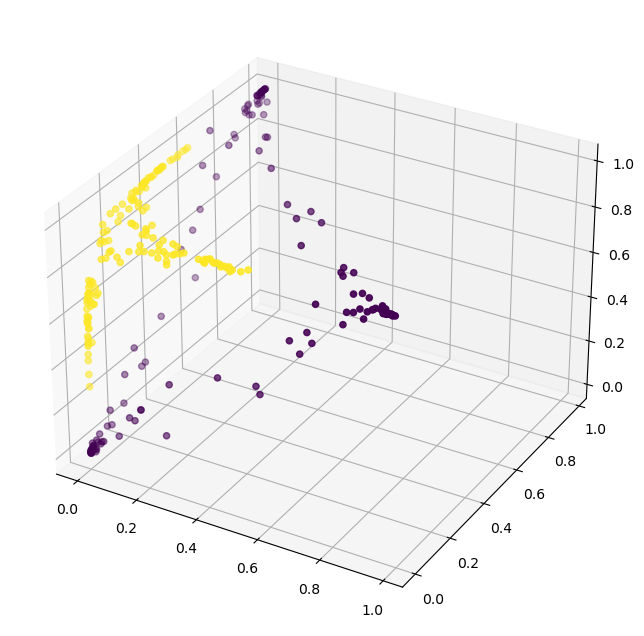

usetex mode requires TeX.


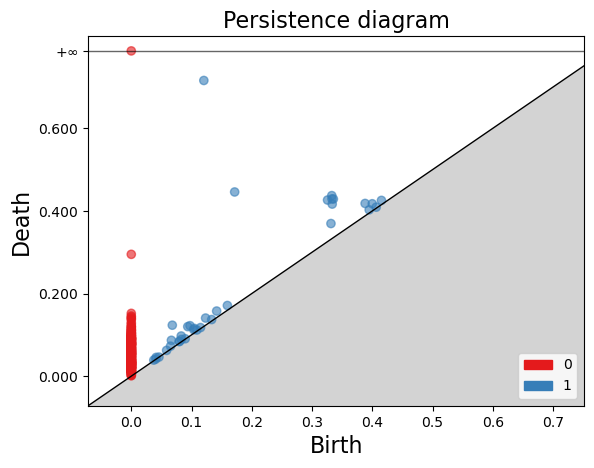

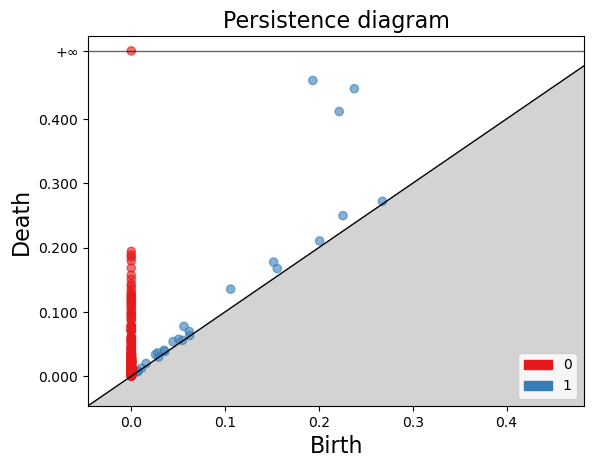

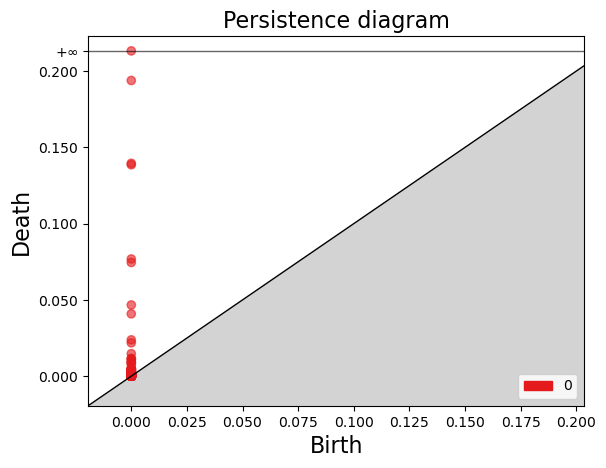

In [7]:
#%% Latent representations
X2 = model.predict(X)

plt.scatter(X[:,0], X[:,1], c=X2>0.5)
plt.show()

hidden_layer_model = Model(
    inputs= model.get_layer(index=0).input,
    outputs=model.get_layer('hidden_layer').output
)

X1 = hidden_layer_model.predict(X)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(X1[:,0],X1[:,1],X1[:,2],c = X2>0.5)
plt.show()

# Layer persistence diagrams
def compute_plot_pd(X,max_dim = 2):
    dm = cdist(X, X)
    simplex_tree = gd.SimplexTree.create_from_array(dm, max_filtration=3)
    simplex_tree.expansion(max_dim)
    persistence = simplex_tree.persistence(homology_coeff_field = 2)
    gd.plot_persistence_diagram(persistence)
    plt.show()
    return simplex_tree
st0 = compute_plot_pd(X,max_dim=2)
st1 = compute_plot_pd(X1,max_dim=2)
st2 = compute_plot_pd(X2,max_dim=0)

## MLP persistence

<AxesSubplot: title={'center': 'Persistence barcode'}>

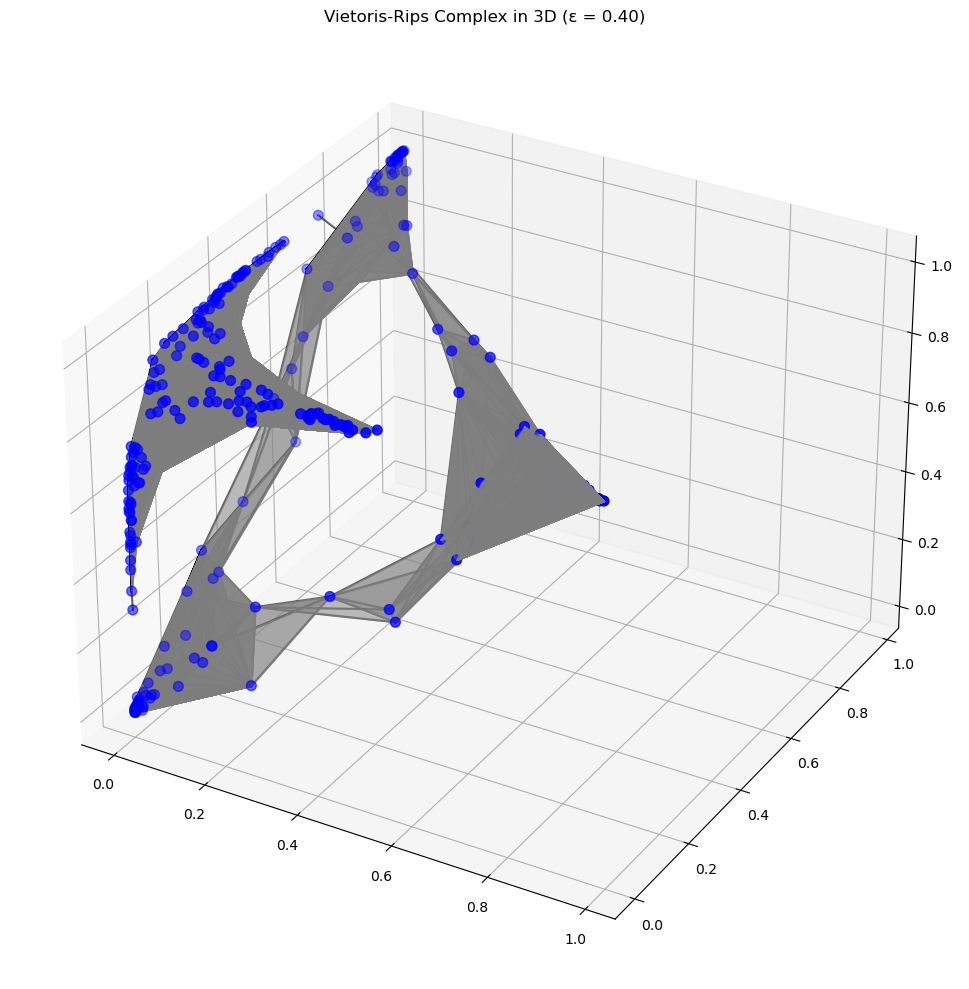

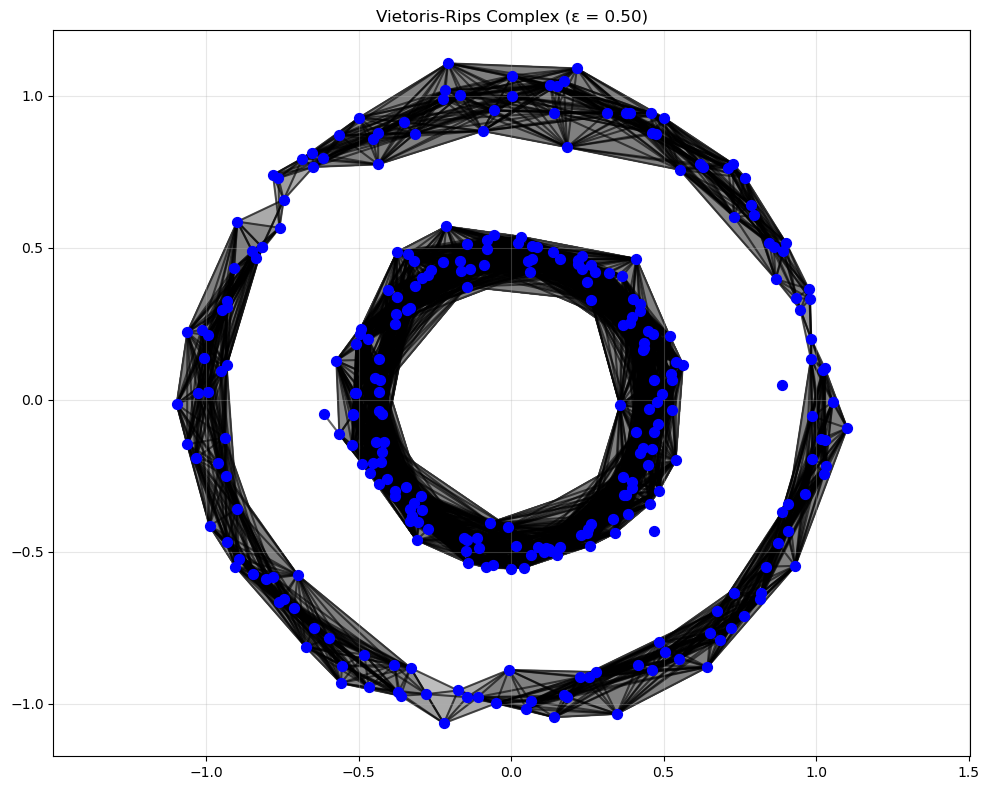

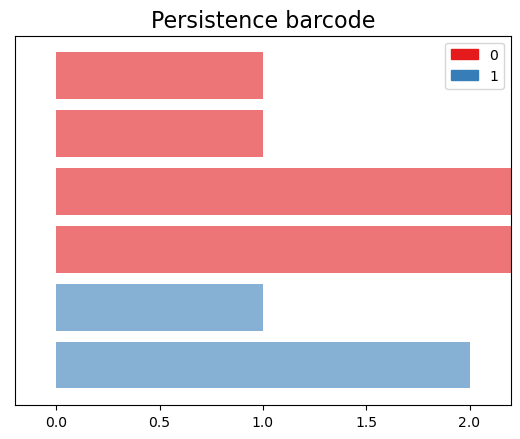

In [8]:
#%% VR-complexes and pullback
epsilon_values = [0.5,0.4,0.2]
X2_2 = np.c_[ X2, X2>0.5]
st2 = compute_vietoris_rips_complex(X2_2,epsilon_values[2],max_dimension=1)

ms2 = get_maximal_simplices(st2, epsilon_values[2])

k1 = vr_pullback(X1, epsilon_values[1], ms2, max_dimension=2)
visualize_vr_complex_3d(X1, k1, epsilon_values[1], show_labels=False)

ms1 = get_maximal_simplices(k1, epsilon_values[1])

k0 = vr_pullback(X, epsilon_values[0], ms1, max_dimension=2)
visualize_vr_complex_2d(X, k0, epsilon_values[0], show_labels=False)


# Expanding the simplices to the desired dimension
k0.expansion(1)
k1.expansion(2)

# Diagrams H0
simplex_trees_by_layer=[k0,k1,st2]
k=create_combined_filtration(simplex_trees_by_layer)
k.compute_persistence()
intervals0 = k.persistence_intervals_in_dimension(0)


# Diagrams H1
simplex_trees_by_layer=[k0,k1]
k=create_combined_filtration(simplex_trees_by_layer)
k.compute_persistence()
intervals1 = k.persistence_intervals_in_dimension(1)


pds = {}
pds[0] = intervals0
pds[1] = intervals1


l = []
for i in [0,1]:
    for [j,k] in pds[i]:
        if i==1:
            if k == np.inf:
                l.append((i,(j,2)))
            else:
                l.append((i,(j,k)))
        else:
            l.append((i,(j,k)))
            
gd.plot_persistence_barcode(l)


## Trajectories

Layer 0: 4 communities detected


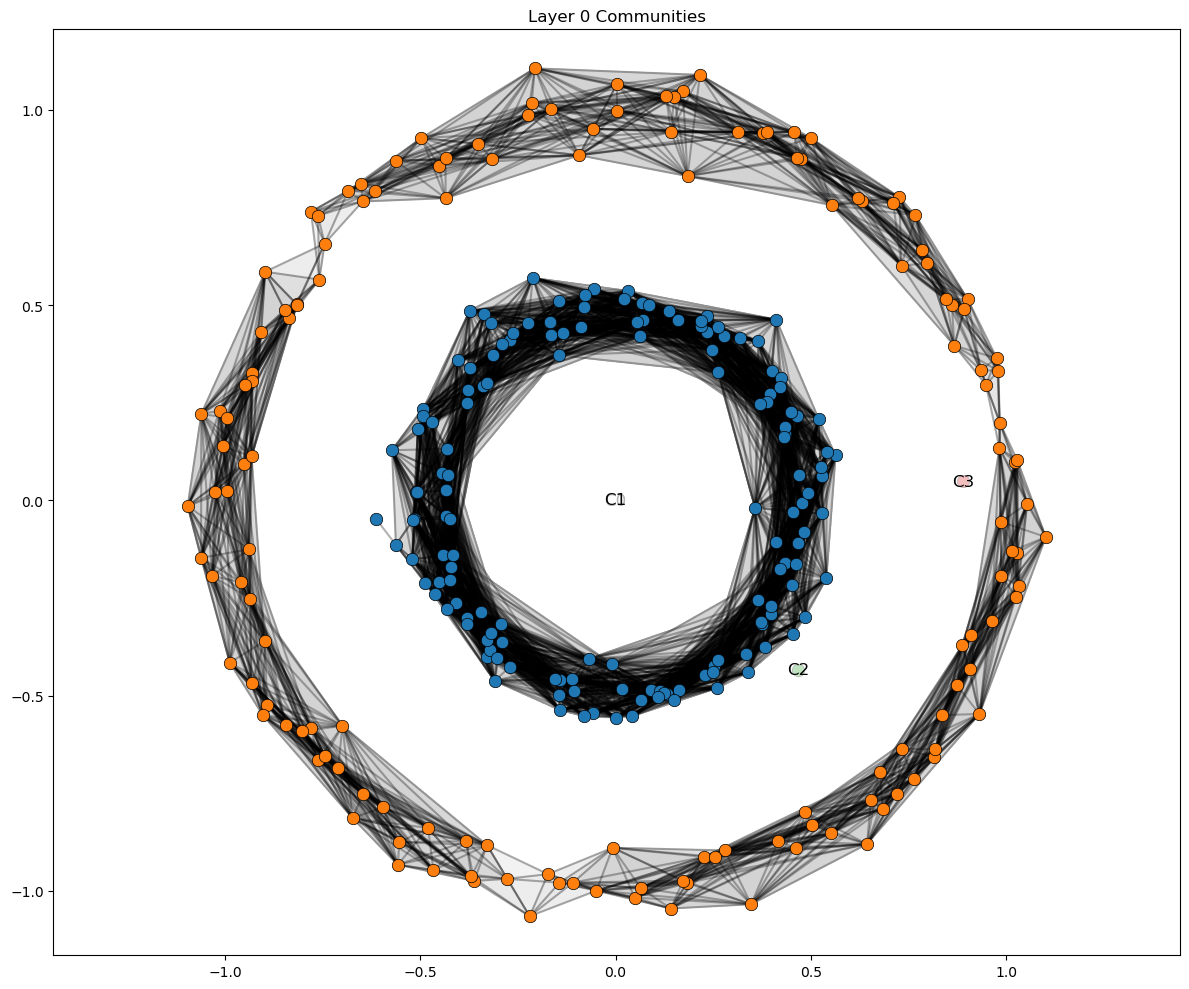

Layer 1: 2 communities detected


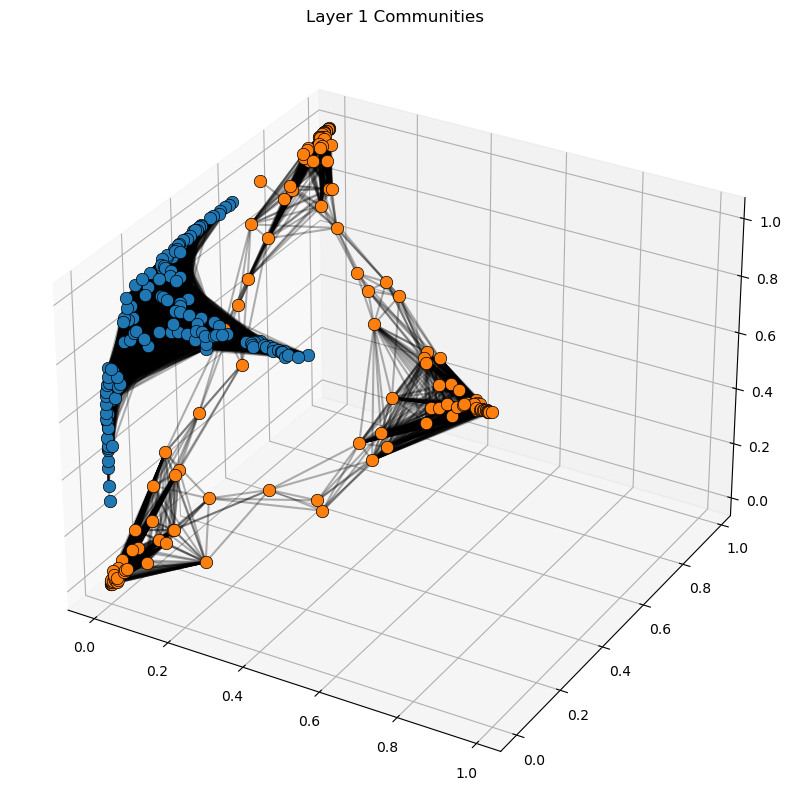

Layer 2: 2 communities detected


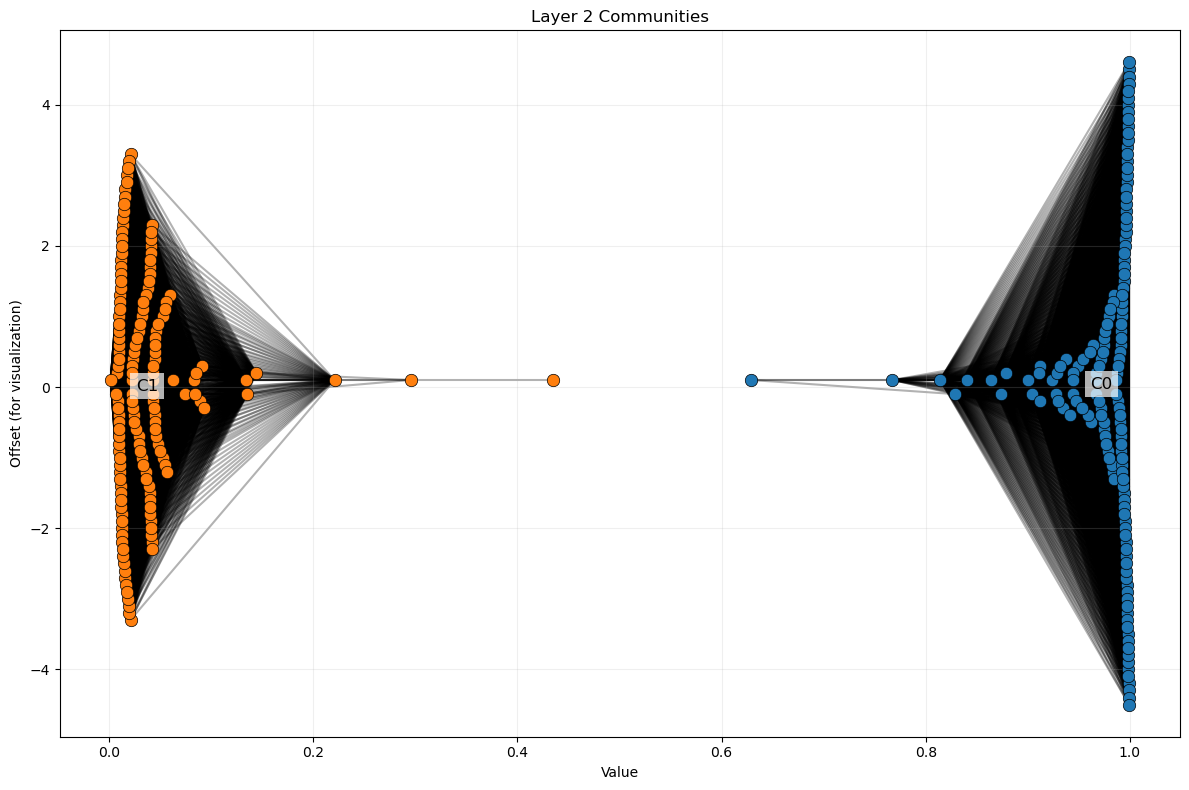

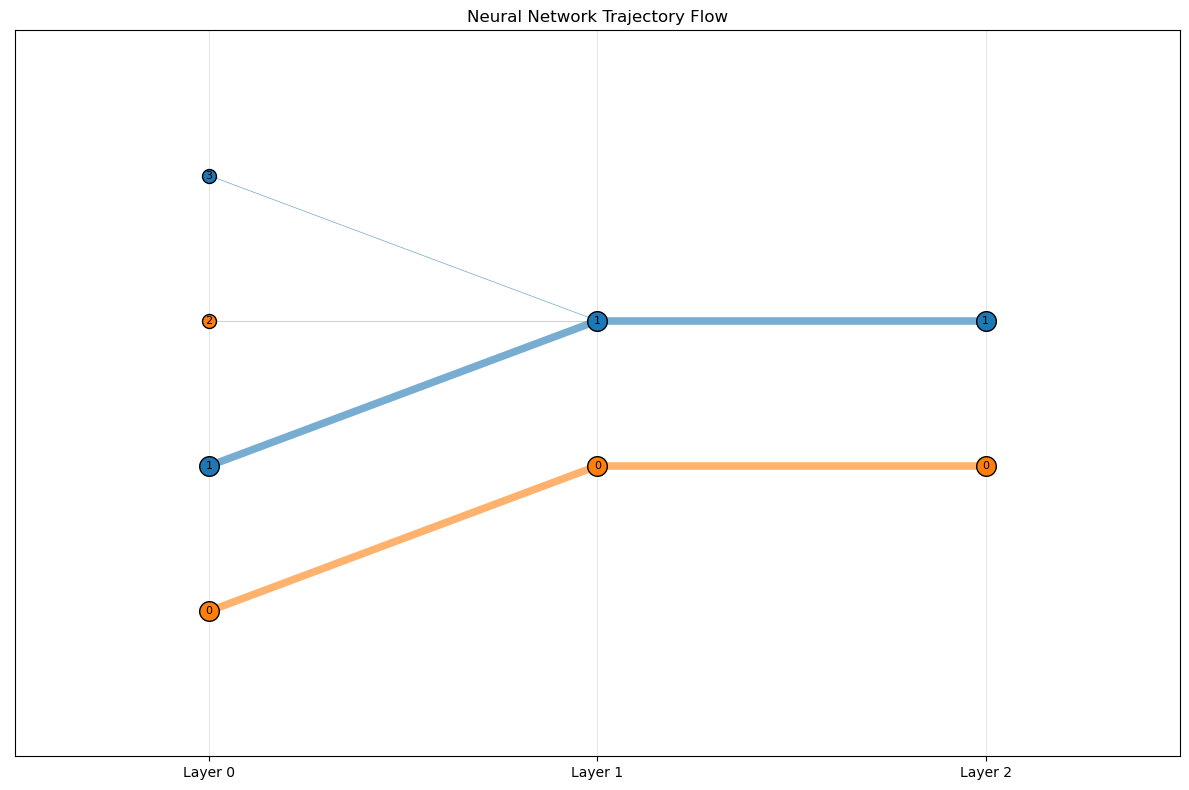


Top trajectories by size:
Trajectory 1: (0, 0, 0) - 149 points
Trajectory 2: (1, 1, 1) - 149 points
Trajectory 3: (2, 1, 1) - 1 points
Trajectory 4: (3, 1, 1) - 1 points

Average trajectory purity: 1.00

Class distribution for top trajectories:
Trajectory 1: (0, 0, 0) - Purity: 1.00
  Class 1: 149 points (100.0%)
Trajectory 2: (1, 1, 1) - Purity: 1.00
  Class 0: 149 points (100.0%)
Trajectory 3: (2, 1, 1) - Purity: 1.00
  Class 1: 1 points (100.0%)
Trajectory 4: (3, 1, 1) - Purity: 1.00
  Class 0: 1 points (100.0%)

Perfect class separation: True


In [9]:
#%% Communities and trajectory analysis
# After computing the VR complexes for each layer
# Define parameters
#epsilon_values = [0.3, 0.2, 0.1]  # For input, hidden, output layers
community_method = 'louvain'      # Community detection method
n_clusters = None                # Auto-detect number of clusters

# Organize data and complexes by layer
data_by_layer = [X, X1, X2]  # Input, hidden, output
simplex_trees_by_layer = [
    k0,
    k1,  # Your pullback complex for hidden layer
    st2  # Your VR complex for output layer
]

# Extract 1-skeleton graphs and identify communities
graphs_by_layer = []
communities_by_layer = []

for i, (points, st) in enumerate(zip(data_by_layer, simplex_trees_by_layer)):
    # Extract 1-skeleton graph
    G = extract_1_skeleton_graph(st, epsilon_values[i])
    graphs_by_layer.append(G)
    
    # Identify communities (connected components or using community detection)
    communities = nx.connected_components(G)#identify_communities(G, method=community_method)
    communities = {}
    ids = 0
    for c in list(nx.connected_components(G)):
        for v in c:
            communities[v]=ids
        ids+=1
    communities_by_layer.append(communities)
    
    # Print community statistics
    unique_communities = set(communities.values())
    print(f"Layer {i}: {len(unique_communities)} communities detected")
    
    # Visualize communities
    if points.shape[1] <= 3:
        visualize_communities(
            points, G, communities, 
            simplex_tree=st, epsilon=epsilon_values[i],
            title=f"Layer {i} Communities"
        )
        plt.show()

# Compute trajectories
trajectories = {}
for point_idx in range(len(data_by_layer[0])):
    trajectory = []
    
    # Get community assignment for this point in each layer
    for i in range(len(data_by_layer)):
        communities = communities_by_layer[i]
        if point_idx in communities:
            trajectory.append(communities[point_idx])
        else:
            # Point might not be in the graph (isolated)
            trajectory.append(-1)
    
    trajectories[point_idx] = trajectory

# Visualize trajectory flow
visualize_trajectory_flow(trajectories, len(data_by_layer), class_labels=y)
plt.show()



# Run trajectory analysis
analysis = analyze_trajectories(trajectories, y)